<a href="https://colab.research.google.com/github/ritammondal2004/Optimizing_Delivery_ETAs/blob/main/Notebooks/ETA_project_data_observation.ipynb" target="_parent">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/IITG 2026 /delivery_data.csv")
df

,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,...,cutoff_timestamp,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor
0,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:27:55,10.435660,14.0,11.0,11.9653,1.272727,14.0,11.0,11.9653,1.272727
1,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:17:55,18.936842,24.0,20.0,21.7243,1.200000,10.0,9.0,9.7590,1.111111
2,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:01:19.505586,27.637279,40.0,28.0,32.5395,1.428571,16.0,7.0,10.8152,2.285714
3,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 03:39:57,36.118028,62.0,40.0,45.5620,1.550000,21.0,12.0,13.0224,1.750000
4,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 03:33:55,39.386040,68.0,44.0,54.2181,1.545455,6.0,5.0,3.9153,1.200000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
144862,training,2018-09-20 16:24:28.436231,thanos::sroute:f0569d2f-4e20-4c31-8542-67b86d5...,Carting,trip-153746066843555182,IND131028AAB,Sonipat_Kundli_H (Haryana),IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),2018-09-20 16:24:28.436231,...,2018-09-20 21:57:20,45.258278,94.0,60.0,67.9280,1.566667,12.0,12.0,8.1858,1.000000
144863,training,2018-09-20 16:24:28.436231,thanos::sroute:f0569d2f-4e20-4c31-8542-67b86d5...,Carting,trip-153746066843555182,IND131028AAB,Sonipat_Kundli_H (Haryana),IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),2018-09-20 16:24:28.436231,...,2018-09-20 21:31:18,54.092531,120.0,76.0,85.6829,1.578947,26.0,21.0,17.3725,1.238095
144864,training,2018-09-20 16:24:28.436231,thanos::sroute:f0569d2f-4e20-4c31-8542-67b86d5...,Carting,trip-153746066843555182,IND131028AAB,Sonipat_Kundli_H (Haryana),IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),2018-09-20 16:24:28.436231,...,2018-09-20 21:11:18,66.163591,140.0,88.0,97.0933,1.590909,20.0,34.0,20.7053,0.588235
144865,training,2018-09-20 16:24:28.436231,thanos::sroute:f0569d2f-4e20-4c31-8542-67b86d5...,Carting,trip-153746066843555182,IND131028AAB,Sonipat_Kundli_H (Haryana),IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),2018-09-20 16:24:28.436231,...,2018-09-20 20:53:19,73.680667,158.0,98.0,111.2709,1.612245,17.0,27.0,18.8885,0.629630


In [ ]:
df.columns

Index(['data', 'trip_creation_time', 'route_schedule_uuid', 'route_type',
       'trip_uuid', 'source_center', 'source_name', 'destination_center',
       'destination_name', 'od_start_time', 'od_end_time',
       'start_scan_to_end_scan', 'is_cutoff', 'cutoff_factor',
       'cutoff_timestamp', 'actual_distance_to_destination', 'actual_time',
       'osrm_time', 'osrm_distance', 'factor', 'segment_actual_time',
       'segment_osrm_time', 'segment_osrm_distance', 'segment_factor'],
      dtype='object')

In [ ]:
df.sample(5)

,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,...,cutoff_timestamp,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor
122234,test,2018-10-02 20:45:45.887197,thanos::sroute:366da0f3-1979-4793-973f-27da635...,FTL,trip-153851314588692944,IND562132AAA,Bangalore_Nelmngla_H (Karnataka),IND411033AAA,Pune_Tathawde_H (Maharashtra),2018-10-03 06:40:29.727527,...,2018-10-03 21:47:31,198.537837,236.0,192.0,219.9319,1.229167,21.0,16.0,22.7494,1.312500
138610,training,2018-09-16 20:26:49.997645,thanos::sroute:45b7c64a-4fdf-48e0-a984-963ad50...,Carting,trip-153712960999737600,IND638501AAB,Anthiyour_TherSRT_D (Tamil Nadu),IND641062AAD,Coimbatore_Karayam_H (Tamil Nadu),2018-09-17 04:12:26.203849,...,2018-09-17 05:33:18,39.209108,82.0,40.0,47.0116,2.050000,54.0,13.0,14.8746,4.153846
59986,training,2018-09-13 14:41:13.820603,thanos::sroute:a9af5fc9-2972-4795-b7a7-9fd3cc0...,FTL,trip-153684967382035290,IND000000ACA,Ludhiana_MilrGanj_HB (Punjab),IND160002AAC,Chandigarh_Mehmdpur_H (Punjab),2018-09-14 09:34:38.227752,...,2018-09-14 12:24:12,22.363313,28.0,16.0,23.0099,1.750000,28.0,16.0,23.0099,1.750000
63912,test,2018-10-03 20:24:39.005080,thanos::sroute:911f6f84-2799-473b-8702-b5e3676...,FTL,trip-153859827900482592,IND382430AAB,Ahmedabad_East_H_1 (Gujarat),IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),2018-10-03 20:24:39.005080,...,2018-10-04 14:50:48,220.548039,324.0,184.0,248.1119,1.760870,38.0,18.0,26.3453,2.111111
65864,training,2018-09-13 20:53:28.049107,thanos::sroute:6b53909c-62c8-4c16-8ea1-c746855...,FTL,trip-153687200804882587,IND847103AAA,Benipur_Javahar_D (Bihar),IND847404AAB,Jhanjharpur_Nagar_D (Bihar),2018-09-14 03:05:26.217581,...,2018-09-14 03:41:29,22.551443,53.0,27.0,27.7547,1.962963,53.0,27.0,27.7547,1.962963


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144867 entries, 0 to 144866
Data columns (total 24 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   data                            144867 non-null  object 
 1   trip_creation_time              144867 non-null  object 
 2   route_schedule_uuid             144867 non-null  object 
 3   route_type                      144867 non-null  object 
 4   trip_uuid                       144867 non-null  object 
 5   source_center                   144867 non-null  object 
 6   source_name                     144574 non-null  object 
 7   destination_center              144867 non-null  object 
 8   destination_name                144606 non-null  object 
 9   od_start_time                   144867 non-null  object 
 10  od_end_time                     144867 non-null  object 
 11  start_scan_to_end_scan          144867 non-null  float64
 12  is_cutoff       

In [ ]:
df_train = df[df['data']=='training']
df_test = df[df['data']=='test']

In [ ]:
df_train.shape, df_test.shape

((104858, 24), (40009, 24))

In [ ]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 104858 entries, 0 to 144866
Data columns (total 24 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   data                            104858 non-null  object 
 1   trip_creation_time              104858 non-null  object 
 2   route_schedule_uuid             104858 non-null  object 
 3   route_type                      104858 non-null  object 
 4   trip_uuid                       104858 non-null  object 
 5   source_center                   104858 non-null  object 
 6   source_name                     104729 non-null  object 
 7   destination_center              104858 non-null  object 
 8   destination_name                104758 non-null  object 
 9   od_start_time                   104858 non-null  object 
 10  od_end_time                     104858 non-null  object 
 11  start_scan_to_end_scan          104858 non-null  float64
 12  is_cutoff            

In [ ]:
# ── 1. Parse all datetime columns ──────────────────────────
time_cols = ['trip_creation_time', 'od_start_time',
             'od_end_time', 'cutoff_timestamp']

for col in time_cols:
    df_train[col] = pd.to_datetime(df_train[col], errors='coerce')

print("Nulls after datetime parsing:")
print(df_train[time_cols].isnull().sum())

Nulls after datetime parsing:
trip_creation_time       0
od_start_time            0
od_end_time              0
cutoff_timestamp      2981
dtype: int64


In [ ]:
print(df_train.isnull().sum())


data                                 0
trip_creation_time                   0
route_schedule_uuid                  0
route_type                           0
trip_uuid                            0
source_center                        0
source_name                        129
destination_center                   0
destination_name                   100
od_start_time                        0
od_end_time                          0
start_scan_to_end_scan               0
is_cutoff                            0
cutoff_factor                        0
cutoff_timestamp                  2981
actual_distance_to_destination       0
actual_time                          0
osrm_time                            0
osrm_distance                        0
factor                               0
segment_actual_time                  0
segment_osrm_time                    0
segment_osrm_distance                0
segment_factor                       0
dtype: int64


In [ ]:
# ── 1. Fill name nulls from center codes ───────────────────
df_train['source_name'] = df_train['source_name'].fillna(df_train['source_center'])
df_train['destination_name'] = df_train['destination_name'].fillna(df_train['destination_center'])

print(df_train.isnull().sum())

data                                 0
trip_creation_time                   0
route_schedule_uuid                  0
route_type                           0
trip_uuid                            0
source_center                        0
source_name                          0
destination_center                   0
destination_name                     0
od_start_time                        0
od_end_time                          0
start_scan_to_end_scan               0
is_cutoff                            0
cutoff_factor                        0
cutoff_timestamp                  2981
actual_distance_to_destination       0
actual_time                          0
osrm_time                            0
osrm_distance                        0
factor                               0
segment_actual_time                  0
segment_osrm_time                    0
segment_osrm_distance                0
segment_factor                       0
dtype: int64


In [ ]:
# ── 3. Drop cutoff_timestamp (too many nulls, not useful) ───
df_train = df_train.drop(columns=['cutoff_timestamp', 'data'])

# ── 4. Remove bad rows ──────────────────────────────────────
df_train = df_train[df_train['segment_actual_time'] > 0].copy()
df_train = df_train[df_train['segment_osrm_time'] > 0].copy()

In [ ]:
# ── 5. Create derived columns ───────────────────────────────
df_train['segment_delay_ratio'] = (
    df_train['segment_actual_time'] / df_train['segment_osrm_time']
)
df_train['trip_delay_ratio'] = (
    df_train['actual_time'] / df_train['osrm_time']
)

In [ ]:
df_train['segment_delay_ratio_capped'] = (
    df_train['segment_delay_ratio'].clip(0.1, 10)
)
df_train['segment_is_delayed'] = df_train['segment_delay_ratio'] > 1.2
df_train['trip_is_delayed']    = df_train['trip_delay_ratio'] > 1.2


In [ ]:
df_train.shape

(103049, 27)

In [ ]:
# ── 6. Extract time features ────────────────────────────────
df_train['hour_of_day'] = df_train['od_start_time'].dt.hour
df_train['day_of_week'] = df_train['od_start_time'].dt.dayofweek
df_train['month']       = df_train['od_start_time'].dt.month

# ── 7. Final verification ───────────────────────────────────
print("Shape:", df_train.shape)
print("\nAny nulls:")
print(df_train.isnull().sum()[df_train.isnull().sum() > 0])
print("\nAny inf in delay ratio:", np.isinf(df_train['segment_delay_ratio']).sum())


Shape: (103049, 30)

Any nulls:
Series([], dtype: int64)

Any inf in delay ratio: 0


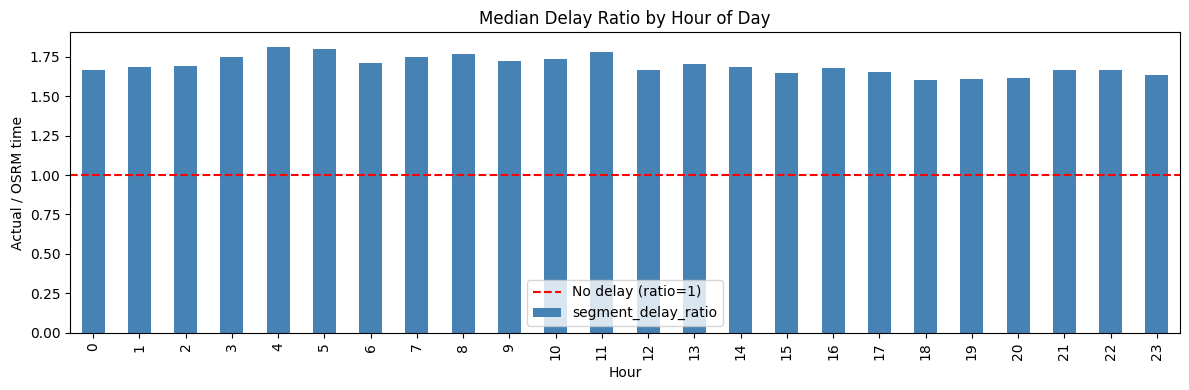

In [ ]:
# ── Does hour of day matter? ────────────────────────────────
hourly = df_train.groupby('hour_of_day')['segment_delay_ratio'].median()

plt.figure(figsize=(12,4))
hourly.plot(kind='bar', color='steelblue')
plt.axhline(1.0, color='red', linestyle='--', label='No delay (ratio=1)')
plt.title('Median Delay Ratio by Hour of Day')
plt.xlabel('Hour'); plt.ylabel('Actual / OSRM time')
plt.legend(); plt.tight_layout(); plt.show()

In [ ]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 39218 entries, 35 to 144800
Data columns (total 27 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   trip_creation_time              39218 non-null  object 
 1   route_schedule_uuid             39218 non-null  object 
 2   route_type                      39218 non-null  object 
 3   trip_uuid                       39218 non-null  object 
 4   source_center                   39218 non-null  object 
 5   source_name                     39218 non-null  object 
 6   destination_center              39218 non-null  object 
 7   destination_name                39218 non-null  object 
 8   od_start_time                   39218 non-null  object 
 9   od_end_time                     39218 non-null  object 
 10  start_scan_to_end_scan          39218 non-null  float64
 11  is_cutoff                       39218 non-null  bool   
 12  cutoff_factor                   392

## same apply on test data


In [ ]:
# ── Same for df_test ────────────────────────────────────────
df_test['source_name'] = df_test['source_name'].fillna(df_test['source_center'])
df_test['destination_name'] = df_test['destination_name'].fillna(df_test['destination_center'])

df_test = df_test.drop(columns=['cutoff_timestamp', 'data'])
time_cols = ['trip_creation_time', 'od_start_time',
             'od_end_time']

for col in time_cols:
    # Only convert if the column exists in df_test, as cutoff_timestamp is dropped later
    if col in df_test.columns:
        df_test[col] = pd.to_datetime(df_test[col], errors='coerce')


df_test = df_test[df_test['segment_actual_time'] > 0].copy()
df_test = df_test[df_test['segment_osrm_time'] > 0].copy()

df_test['segment_delay_ratio'] = (
    df_test['segment_actual_time'] / df_test['segment_osrm_time']
)
df_test['trip_delay_ratio'] = (
    df_test['actual_time'] / df_test['osrm_time']
)
df_test['segment_delay_ratio_capped'] = (
    df_test['segment_delay_ratio'].clip(0.1, 10)
)
df_test['segment_is_delayed'] = df_test['segment_delay_ratio'] > 1.2
df_test['trip_is_delayed']    = df_test['trip_delay_ratio'] > 1.2
df_test['hour_of_day'] = df_test['od_start_time'].dt.hour
df_test['day_of_week'] = df_test['od_start_time'].dt.dayofweek
df_test['month']       = df_test['od_start_time'].dt.month

print("Test shape:", df_test.shape)


Test shape: (39218, 30)


In [ ]:
df_train.to_csv('df_train.csv', index=False)
df_test.to_csv('df_test.csv', index=False)

In [ ]:
df_train = pd.read_csv('/content/df_train.csv')
df_test = pd.read_csv('/content/df_test.csv')



#Graph construction
### ── Step 1: Compute edge weights stratified by route_type & time of day

In [ ]:
# ── Step 1: Compute edge weights stratified by route_type & time of day
corridor_stats = df_train.groupby(
    ['source_center', 'destination_center', 'route_type', 'hour_of_day']
).agg(
    median_delay_ratio = ('segment_delay_ratio_capped', 'median'),
    mean_actual_time   = ('segment_actual_time', 'mean'),
    mean_osrm_time     = ('segment_osrm_time', 'mean'),
    trip_count         = ('trip_uuid', 'count')
).reset_index()

print("Corridor stats shape:", corridor_stats.shape)
corridor_stats.head()

Corridor stats shape: (6690, 8)


,source_center,destination_center,route_type,hour_of_day,median_delay_ratio,mean_actual_time,mean_osrm_time,trip_count
0,IND000000AAL,IND411033AAA,Carting,0,1.950000,26.000000,13.500000,2
1,IND000000AAL,IND411033AAA,Carting,6,3.197436,43.500000,14.000000,2
2,IND000000AAL,IND411033AAA,Carting,12,2.333333,31.250000,13.250000,4
3,IND000000AAL,IND411033AAA,Carting,13,2.500000,55.555556,16.777778,9
4,IND000000AAL,IND411033AAA,Carting,18,1.884615,24.500000,13.000000,2


In [ ]:
for (src, dst), group in corridor_stats.groupby(
    ['source_center', 'destination_center']
):
    print(f"\n{src} -> {dst}")
    print(group)

Streaming output truncated to the last 5000 lines.
5487            1.833333         24.583333            12.5          24  

IND680104AAA -> IND679576AAA
     source_center destination_center route_type  hour_of_day  \
5488  IND680104AAA       IND679576AAA        FTL            0   
5489  IND680104AAA       IND679576AAA        FTL            1   

      median_delay_ratio  mean_actual_time  mean_osrm_time  trip_count  
5488            1.575758         41.636364       27.545455          11  
5489            1.401961         38.250000       25.750000           4  

IND680307AAA -> IND680712AAA
     source_center destination_center route_type  hour_of_day  \
5490  IND680307AAA       IND680712AAA    Carting            1   
5491  IND680307AAA       IND680712AAA    Carting            2   

      median_delay_ratio  mean_actual_time  mean_osrm_time  trip_count  
5490            1.703297              16.5        9.833333           6  
5491            1.867521              20.5       11.000000 

### ── Step 2: Build graph (one edge per corridor,
###            but carry stratified stats as edge attribute)

In [ ]:
import networkx as nx
G = nx.DiGraph()

# Group by corridor only for the graph edges
# Store the full stratified breakdown as an attribute
for (src, dst), group in corridor_stats.groupby(
    ['source_center', 'destination_center']
):
    # Overall median across all route types and hours
    overall_median = group['median_delay_ratio'].median()

    # Breakdown by route_type
    by_route = group.groupby('route_type')['median_delay_ratio'].median().to_dict()

    # Breakdown by hour (peak hours 8-20 vs off-peak)
    group['time_bucket'] = group['hour_of_day'].apply(
        lambda h: 'peak' if 8 <= h <= 20 else 'off_peak'
    )
    by_time = group.groupby('time_bucket')['median_delay_ratio'].median().to_dict()

    G.add_edge(
        src, dst,
        weight          = overall_median,      # primary edge weight
        delay_by_route  = by_route,            # {'FTL': x, 'CARTING': y}
        delay_by_time   = by_time,             # {'peak': x, 'off_peak': y}
        trip_count      = group['trip_count'].sum()
    )

print(f"\nNodes (facilities): {G.number_of_nodes()}")
print(f"Edges (corridors):  {G.number_of_edges()}")


Nodes (facilities): 1590
Edges (corridors):  2508


### visual summary

In [ ]:
# Before graph (just a table):
# ┌─────────┬─────────┬───────┬──────┬──────────────┐
# │ source  │  dest   │ route │ hour │ delay_ratio  │
# ├─────────┼─────────┼───────┼──────┼──────────────┤
# │ Delhi   │ Mumbai  │ FTL   │  14  │    1.65      │
# │ Delhi   │ Mumbai  │ CART  │  14  │    1.91      │
# │ Delhi   │ Nagpur  │ FTL   │  22  │    1.45      │
# └─────────┴─────────┴───────┴──────┴──────────────┘

# After graph (connected network):
#          1.70 (FTL:1.65, CART:1.91)
# Delhi ────────────────────────────→ Mumbai
#   │
#   │ 1.45
#   ↓
# Nagpur ──────────────────────────→ ...

In [ ]:
type(G.edges(data=True))

networkx.classes.reportviews.OutEdgeDataView

In [ ]:
list(G.edges(data=True))[4]

('IND411033AAA',
 'IND403726AAA',
 {'weight': 1.6967697335344394,
  'delay_by_route': {'FTL': 1.6967697335344394},
  'delay_by_time': {'off_peak': 1.6944444444444444,
   'peak': 1.6990950226244343},
  'trip_count': np.int64(335)})

In [ ]:
# ── Step 3: Verify a sample edge has all attributes ─────────
sample_edge = list(G.edges(data=True))[0]
print("\nSample edge:")
print(f"  From:           {sample_edge[0]}")
print(f"  To:             {sample_edge[1]}")
print(f"  Weight:         {sample_edge[2]['weight']:.3f}")
print(f"  By route type:  {sample_edge[2]['delay_by_route']}")
print(f"  By time bucket: {sample_edge[2]['delay_by_time']}")
print(f"  Trip count:     {sample_edge[2]['trip_count']}")


Sample edge:
  From:           IND000000AAL
  To:             IND411033AAA
  Weight:         2.142
  By route type:  {'Carting': 2.1416666666666666}
  By time bucket: {'off_peak': 1.95, 'peak': 2.333333333333333}
  Trip count:     27


#Bottleneck Analysis (Graph Metrics)
#### This is where NetworkX really shines. Three metrics to compute:


#### 1. Betweenness Centrality


Top 10 chokepoint hubs:
          facility  betweenness
23    IND000000ACB     0.233721
10    IND562132AAA     0.150710
64    IND712311AAA     0.082463
61    IND501359AAE     0.074204
22    IND160002AAC     0.049852
1     IND411033AAA     0.044648
45    IND131028AAB     0.044132
1323  IND781018AAB     0.043732
63    IND600056AAB     0.043193
58    IND421302AAG     0.039954


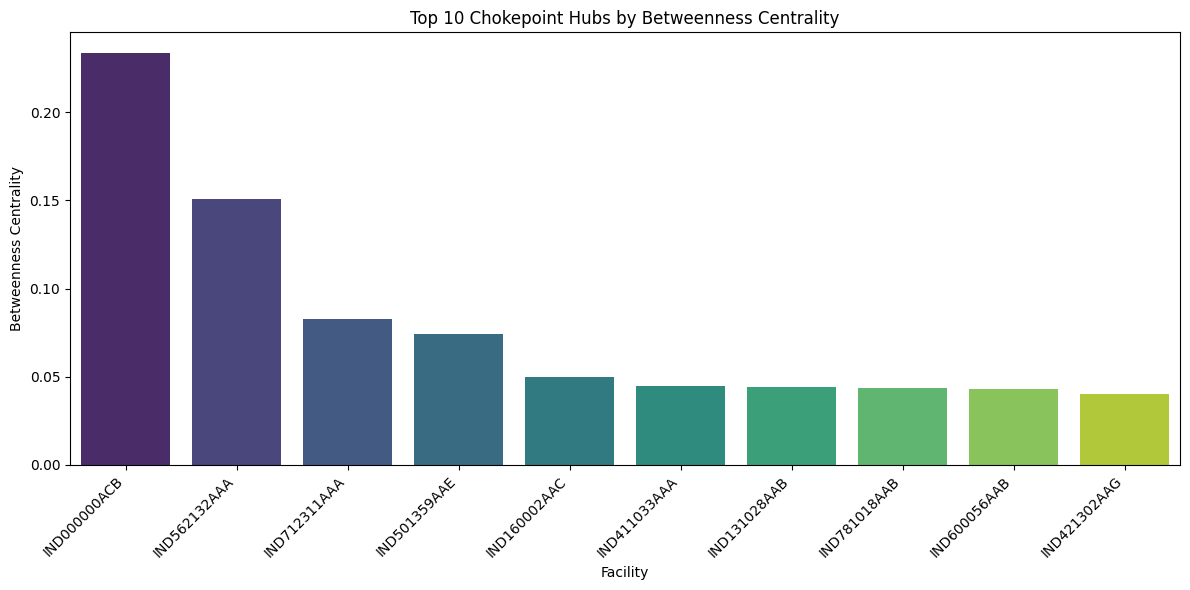

In [ ]:
# Which hubs sit on the most paths between other hubs?
# These are your chokepoints
import networkx as nx
import seaborn as sns

betweenness = nx.betweenness_centrality(G, weight='weight')

# Convert to dataframe
betweenness_df = pd.DataFrame({
    'facility'    : list(betweenness.keys()),
    'betweenness' : list(betweenness.values())
}).sort_values('betweenness', ascending=False)

print("Top 10 chokepoint hubs:")
print(betweenness_df.head(10))

plt.figure(figsize=(12, 6))
sns.barplot(x='facility', y='betweenness', data=betweenness_df.head(10), palette='viridis')
plt.title('Top 10 Chokepoint Hubs by Betweenness Centrality')
plt.xlabel('Facility')
plt.ylabel('Betweenness Centrality')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# How many corridors feed INTO vs leave a hub?

in_degree  = dict(G.in_degree())
out_degree = dict(G.out_degree())

degree_df = pd.DataFrame({
    'facility'   : list(in_degree.keys()),
    'in_degree'  : list(in_degree.values()),
    'out_degree' : [out_degree[n] for n in in_degree.keys()]
})

# Total connectivity of each hub
degree_df['total_degree'] = degree_df['in_degree'] + degree_df['out_degree']
degree_df = degree_df.sort_values('total_degree', ascending=False)

print("\nTop 10 most connected hubs:")
print(degree_df.head(10))

import plotly.express as px

# Prepare data for plotting
plot_df = degree_df.head(10).melt(id_vars=['facility'], value_vars=['in_degree', 'out_degree'], var_name='Degree Type', value_name='Count')

fig = px.bar(plot_df, x='facility', y='Count', color='Degree Type',
             title='Top 10 Most Connected Hubs by In and Out Degree',
             labels={'facility': 'Facility', 'Count': 'Number of Edges'},
             category_orders={'facility': degree_df.head(10)['facility'].tolist()}) # Maintain sorting

fig.update_layout(xaxis_title="Facility", yaxis_title="Number of Corridors", hovermode="x unified")
fig.show()


Top 10 most connected hubs:
        facility  in_degree  out_degree  total_degree
23  IND000000ACB         41          48            89
10  IND562132AAA         36          35            71
22  IND160002AAC         30          28            58
61  IND501359AAE         30          27            57
58  IND421302AAG         27          27            54
64  IND712311AAA         21          21            42
1   IND411033AAA         22          19            41
97  IND110037AAM         19          22            41
45  IND131028AAB         19          18            37
63  IND600056AAB         18          18            36


###3. Chronically Delayed Corridors

In [ ]:
# Which specific routes are ALWAYS late? (>20% over OSRM)

delayed_corridors = []

for src, dst, data in G.edges(data=True):
    delayed_corridors.append({
        'source'       : src,
        'destination'  : dst,
        'delay_ratio'  : data['weight'],
        'trip_count'   : data['trip_count'],
        'delay_by_route': data['delay_by_route'],
        'delay_by_time' : data['delay_by_time']
    })

corridors_df = pd.DataFrame(delayed_corridors)
corridors_df = corridors_df.sort_values('delay_ratio', ascending=False)

print("\nTop 10 worst corridors:")
print(corridors_df.head(10))

print(f"\nCorridors >20% delayed: {(corridors_df['delay_ratio'] > 1.2).sum()}")
print(f"Corridors >50% delayed: {(corridors_df['delay_ratio'] > 1.5).sum()}")
print(f"Corridors >2x delayed:  {(corridors_df['delay_ratio'] > 2.0).sum()}")


Top 10 worst corridors:
            source   destination  delay_ratio  trip_count     delay_by_route  \
2472  IND844505AAB  IND842001AAA         10.0          11      {'FTL': 10.0}   
2470  IND847223AAA  IND842001AAA         10.0          11      {'FTL': 10.0}   
1398  IND482002AAA  IND842003AAB         10.0           2  {'Carting': 10.0}   
1313  IND425409AAA  IND424006AAA         10.0           1      {'FTL': 10.0}   
1300  IND424304AAC  IND424006AAA         10.0           2      {'FTL': 10.0}   
2378  IND788713AAA  IND788026AAC         10.0           1      {'FTL': 10.0}   
406   IND751002AAB  IND754103AAA         10.0           9      {'FTL': 10.0}   
1303  IND425405AAA  IND424006AAA         10.0          12      {'FTL': 10.0}   
1360  IND842003AAB  IND482002AAA         10.0           2  {'Carting': 10.0}   
1309  IND424201AAA  IND424006AAA         10.0           1  {'Carting': 10.0}   

                         delay_by_time  
2472                {'off_peak': 10.0}  
2470        

In [ ]:
import plotly.express as px

fig = px.scatter(corridors_df,
                 x='trip_count',
                 y='delay_ratio',
                 hover_name='source',
                 hover_data=['destination', 'delay_by_route', 'delay_by_time'],
                 title='Corridor Delay Ratio vs. Trip Count (Interactive)',
                 labels={'trip_count': 'Total Trip Count', 'delay_ratio': 'Median Delay Ratio'})

fig.update_layout(xaxis_title="Total Trip Count", yaxis_title="Median Delay Ratio", hovermode="closest")
fig.show()

###4. Combine Everything Into One Hub Risk Table

In [ ]:
# Merge all metrics into single hub summary

hub_risk = betweenness_df.merge(degree_df, on='facility')

# Add average delay of corridors passing through each hub
hub_delay = corridors_df.groupby('source')['delay_ratio'].mean().reset_index()
hub_delay.columns = ['facility', 'avg_outgoing_delay']

hub_risk = hub_risk.merge(hub_delay, on='facility', how='left')

# Create a simple risk score
# High betweenness + high delay = most dangerous hub
hub_risk['risk_score'] = (
    hub_risk['betweenness'] * hub_risk['avg_outgoing_delay']
)

hub_risk = hub_risk.sort_values('risk_score', ascending=False)

print("\nTop 10 highest risk hubs:")
print(hub_risk.head(10))

# -------------------------------

import plotly.express as px

fig = px.bar(hub_risk.head(10), x='facility', y='risk_score',
             title='Top 10 Highest Risk Hubs',
             labels={'facility': 'Facility', 'risk_score': 'Risk Score'},
             hover_data=['betweenness', 'in_degree', 'out_degree', 'avg_outgoing_delay'],
             text=hub_risk.head(10)['risk_score'].apply(lambda x: f'{x:.3f}')) # Add text for annotations

fig.update_traces(textposition='outside') # Position text outside the bars
fig.update_layout(xaxis_title="Facility", yaxis_title="Risk Score", hovermode="x unified")
fig.show()


Top 10 highest risk hubs:
        facility  betweenness  in_degree  out_degree  total_degree  \
0   IND000000ACB     0.233721         41          48            89   
1   IND562132AAA     0.150710         36          35            71   
2   IND712311AAA     0.082463         21          21            42   
3   IND501359AAE     0.074204         30          27            57   
7   IND781018AAB     0.043732         15          14            29   
9   IND421302AAG     0.039954         27          27            54   
6   IND131028AAB     0.044132         19          18            37   
4   IND160002AAC     0.049852         30          28            58   
5   IND411033AAA     0.044648         22          19            41   
11  IND110037AAM     0.035985         19          22            41   

    avg_outgoing_delay  risk_score  
0             1.590786    0.371800  
1             1.566733    0.236122  
2             2.402715    0.198136  
3             1.815772    0.134737  
7             2.0

## model training preparation

In [ ]:


# ── 1. Add corridor-level graph features to df_train ───────
# Map between ness centrality onto each row
df_train['src_betweenness'] = df_train['source_center'].map(betweenness)
df_train['dst_betweenness'] = df_train['destination_center'].map(betweenness)

# Map in/out degree
in_degree  = dict(G.in_degree())
out_degree = dict(G.out_degree())

df_train['src_in_degree']   = df_train['source_center'].map(in_degree)
df_train['src_out_degree']  = df_train['source_center'].map(out_degree)
df_train['dst_in_degree']   = df_train['destination_center'].map(in_degree)
df_train['dst_out_degree']  = df_train['destination_center'].map(out_degree)

# Map corridor median delay (from graph edge weight)
edge_weights = {(u,v): d['weight'] for u,v,d in G.edges(data=True)}
df_train['corridor_median_delay'] = df_train.apply(
    lambda r: edge_weights.get(
        (r['source_center'], r['destination_center']), np.nan
    ), axis=1
)

# Fill nulls (corridors not seen in training graph)
df_train['corridor_median_delay'] = df_train['corridor_median_delay'].fillna(
    df_train['corridor_median_delay'].median()
)

print("New features added:")
print(df_train[['src_betweenness','dst_betweenness',
                'src_in_degree','corridor_median_delay']].describe())

New features added:
       src_betweenness  dst_betweenness  src_in_degree  corridor_median_delay
count    103049.000000    103049.000000  103049.000000          103049.000000
mean          0.061246         0.053097      16.262429               1.763157
std           0.084776         0.075746      15.426299               0.575936
min           0.000000         0.000000       0.000000               0.638889
25%           0.000818         0.000827       2.000000               1.500000
50%           0.016350         0.016350      11.000000               1.646008
75%           0.074204         0.074204      30.000000               1.848039
max           0.233721         0.233721      41.000000              10.000000


In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
import numpy as np

# ── 2. Encode route_type ────────────────────────────────────
le = LabelEncoder()
df_train['route_type_encoded'] = le.fit_transform(df_train['route_type'])

# ── 3. Define baseline features (NO graph features) ────────
baseline_features = [
    'segment_osrm_time',
    'segment_osrm_distance',
    'route_type_encoded',
    'hour_of_day',
    'day_of_week',
    'month'
]

# Graph-enhanced features (adds graph info on top)
graph_features = baseline_features + [
    'src_betweenness',
    'dst_betweenness',
    'src_in_degree',
    'src_out_degree',
    'dst_in_degree',
    'dst_out_degree',
    'corridor_median_delay'
]

target = 'segment_actual_time'

# ── 4. Split for validation ─────────────────────────────────
X = df_train[graph_features].dropna()
y = df_train.loc[X.index, target]

X_tr, X_val, y_tr, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training rows:   {len(X_tr)}")
print(f"Validation rows: {len(X_val)}")

Training rows:   82439
Validation rows: 20610


In [ ]:
df_test

,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,od_end_time,...,segment_osrm_distance,segment_factor,segment_delay_ratio,trip_delay_ratio,segment_delay_ratio_capped,segment_is_delayed,trip_is_delayed,hour_of_day,day_of_week,month
0,2018-09-29 22:21:45.149226,thanos::sroute:0904e75c-b3ac-4278-96cf-802835a...,FTL,trip-153825970514894360,IND141003AAB,Ludhiana_GillChwk_DC (Punjab),IND142026AAA,Jagraon_DC (Punjab),2018-09-30 02:22:04.138164,2018-09-30 03:42:55.193293,...,23.8100,1.250000,1.250000,1.250000,1.250000,True,True,2,6,9
1,2018-09-29 22:21:45.149226,thanos::sroute:0904e75c-b3ac-4278-96cf-802835a...,FTL,trip-153825970514894360,IND141003AAB,Ludhiana_GillChwk_DC (Punjab),IND142026AAA,Jagraon_DC (Punjab),2018-09-30 02:22:04.138164,2018-09-30 03:42:55.193293,...,16.8540,1.357143,1.357143,1.290323,1.357143,True,True,2,6,9
2,2018-09-29 22:21:45.149226,thanos::sroute:0904e75c-b3ac-4278-96cf-802835a...,FTL,trip-153825970514894360,IND142026AAA,Jagraon_DC (Punjab),IND141109AAA,Raikot_DC (Punjab),2018-09-30 03:42:55.193293,2018-09-30 05:12:34.503322,...,23.3491,1.457143,1.457143,1.457143,1.457143,True,True,3,6,9
3,2018-09-29 22:21:45.149226,thanos::sroute:0904e75c-b3ac-4278-96cf-802835a...,FTL,trip-153825970514894360,IND141109AAA,Raikot_DC (Punjab),IND000000ACA,Ludhiana_MilrGanj_HB (Punjab),2018-09-30 05:12:34.503322,2018-09-30 06:44:42.320422,...,32.6991,0.911111,0.911111,0.911111,0.911111,False,False,5,6,9
4,2018-09-29 22:21:45.149226,thanos::sroute:0904e75c-b3ac-4278-96cf-802835a...,FTL,trip-153825970514894360,IND141109AAA,Raikot_DC (Punjab),IND000000ACA,Ludhiana_MilrGanj_HB (Punjab),2018-09-30 05:12:34.503322,2018-09-30 06:44:42.320422,...,19.0379,0.740741,0.740741,1.070175,0.740741,False,False,5,6,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39213,2018-10-01 18:17:37.047270,thanos::sroute:4029a8a2-6c74-4b7e-a6d8-f9e069f...,FTL,trip-153841785704702048,IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),IND562132AAA,Bangalore_Nelmngla_H (Karnataka),2018-10-02 09:02:19.284969,2018-10-04 10:12:02.765216,...,28.5248,1.750000,1.750000,1.769437,1.750000,True,True,9,1,10
39214,2018-10-01 18:17:37.047270,thanos::sroute:4029a8a2-6c74-4b7e-a6d8-f9e069f...,FTL,trip-153841785704702048,IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),IND562132AAA,Bangalore_Nelmngla_H (Karnataka),2018-10-02 09:02:19.284969,2018-10-04 10:12:02.765216,...,28.8611,1.750000,1.750000,1.769180,1.750000,True,True,9,1,10
39215,2018-10-01 18:17:37.047270,thanos::sroute:4029a8a2-6c74-4b7e-a6d8-f9e069f...,FTL,trip-153841785704702048,IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),IND562132AAA,Bangalore_Nelmngla_H (Karnataka),2018-10-02 09:02:19.284969,2018-10-04 10:12:02.765216,...,27.4406,1.263158,1.263158,1.762402,1.263158,True,True,9,1,10
39216,2018-10-01 18:17:37.047270,thanos::sroute:4029a8a2-6c74-4b7e-a6d8-f9e069f...,FTL,trip-153841785704702048,IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),IND562132AAA,Bangalore_Nelmngla_H (Karnataka),2018-10-02 09:02:19.284969,2018-10-04 10:12:02.765216,...,36.7167,1.346154,1.346154,1.766301,1.346154,True,True,9,1,10


In [ ]:
# ── 5. Train baseline model ─────────────────────────────────
baseline_model = GradientBoostingRegressor(
    n_estimators=100, random_state=42
)
baseline_model.fit(X_tr[baseline_features], y_tr)
baseline_preds = baseline_model.predict(X_val[baseline_features])


In [ ]:
baseline_model

GradientBoostingRegressor(random_state=42)

In [ ]:
# ── 6. Train graph-enhanced model ──────────────────────────
graph_model = GradientBoostingRegressor(
    n_estimators=100, random_state=42
)
graph_model.fit(X_tr[graph_features], y_tr)
graph_preds = graph_model.predict(X_val[graph_features])

In [ ]:
graph_model

GradientBoostingRegressor(random_state=42)

In [ ]:
# ── 7. Compare both models ──────────────────────────────────
def evaluate(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)

    # Business metric: % trips within 15% of actual
    pct_error = np.abs(y_pred - y_true) / y_true
    within_15 = (pct_error <= 0.15).mean() * 100

    print(f"\n{name}")
    print(f"  MAE:              {mae:.2f} minutes")
    print(f"  Within 15%:       {within_15:.1f}%")

evaluate("Baseline (no graph)", y_val, baseline_preds)
evaluate("Graph-Enhanced",      y_val, graph_preds)


Baseline (no graph)
  MAE:              15.89 minutes
  Within 15%:       21.9%

Graph-Enhanced
  MAE:              14.20 minutes
  Within 15%:       25.0%


### preds from test data

In [ ]:
# ── 1. Map graph features onto df_test ─────────────────────
df_test['src_betweenness'] = df_test['source_center'].map(betweenness)
df_test['dst_betweenness'] = df_test['destination_center'].map(betweenness)

df_test['src_in_degree']  = df_test['source_center'].map(in_degree)
df_test['src_out_degree'] = df_test['source_center'].map(out_degree)
df_test['dst_in_degree']  = df_test['destination_center'].map(in_degree)
df_test['dst_out_degree'] = df_test['destination_center'].map(out_degree)

df_test['corridor_median_delay'] = df_test.apply(
    lambda r: edge_weights.get(
        (r['source_center'], r['destination_center']), np.nan
    ), axis=1
)

# Fill unseen corridors with training median
#train_median = df_train['corridor_median_delay'].median()
df_test['corridor_median_delay'] = df_test['corridor_median_delay'].fillna(train_median)

# ── 2. Encode route_type using SAME encoder from training ───
df_test['route_type_encoded'] = le.transform(df_test['route_type'])

In [ ]:
# ── 3. Prepare test X and y ─────────────────────────────────
X_test = df_test[graph_features].dropna()
y_test = df_test.loc[X_test.index, target]

# ── 4. Evaluate both models on test data ────────────────────
baseline_test_preds = baseline_model.predict(X_test[baseline_features])
graph_test_preds    = graph_model.predict(X_test[graph_features])

evaluate("Baseline — TEST", y_test, baseline_test_preds)
evaluate("Graph-Enhanced — TEST", y_test, graph_test_preds)


Baseline — TEST
  MAE:              16.26 minutes
  Within 15%:       21.2%

Graph-Enhanced — TEST
  MAE:              14.53 minutes
  Within 15%:       23.7%


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate(name, model, X, y, features):
    # Predictions done inside
    y_pred = model.predict(X[features])
    y_true = y.values

    mae   = mean_absolute_error(y_true, y_pred)
    rmse  = np.sqrt(mean_squared_error(y_true, y_pred))
    r2    = r2_score(y_true, y_pred)

    pct_error = np.abs(y_pred - y_true) / y_true
    within_15 = (pct_error <= 0.15).mean() * 100
    mape      = pct_error.mean() * 100

    print(f"\n{'='*40}")
    print(f"  {name}")
    print(f"{'='*40}")
    print(f"  MAE          : {mae:.2f} mins")
    print(f"  RMSE         : {rmse:.2f} mins")
    print(f"  R2 Score     : {r2:.4f}")
    print(f"  MAPE         : {mape:.2f}%")
    print(f"  Within 15%   : {within_15:.1f}%")

# ── Call it ─────────────────────────────────────────────────
evaluate("Baseline — TEST",       baseline_model, X_test, y_test, baseline_features)
evaluate("Graph-Enhanced — TEST", graph_model,    X_test, y_test, graph_features)


  Baseline — TEST
  MAE          : 16.26 mins
  RMSE         : 51.52 mins
  R2 Score     : 0.1521
  MAPE         : 55.98%
  Within 15%   : 21.2%

  Graph-Enhanced — TEST
  MAE          : 14.53 mins
  RMSE         : 43.39 mins
  R2 Score     : 0.3985
  MAPE         : 50.34%
  Within 15%   : 23.7%


# Now building final enhanced model

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor, BaggingRegressor
from sklearn.model_selection import cross_val_score, KFold
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import numpy as np

# ── Define all models to try ────────────────────────────────
models = {
    'Random Forest'        : RandomForestRegressor(
                                n_estimators=150,
                                random_state=42,
                                criterion = 'friedman_mse',
                                min_samples_leaf =2
                             ),
    'Gradient Boosting'    : GradientBoostingRegressor(
                                n_estimators=200,
                                random_state=42
                             ),
    'XGBoost'              : XGBRegressor(
                                n_estimators=100,
                                random_state=42,
                                n_jobs=-1,
                                verbosity=0
                             ),
    'Bagging'              : BaggingRegressor(
                                n_estimators=50,
                                random_state=42,
                                n_jobs=-1
                             ),
}

In [ ]:
# ── Cross validation on all models ──────────────────────────
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {}

for name, model in models.items():
    # Use graph_features (best feature set)
    scores = cross_val_score(
        model,
        X_tr[graph_features],
        y_tr,
        cv      = kf,
        scoring = 'r2',
        n_jobs  = -1
    )
    cv_results[name] = scores
    print(f"{name:25s} | Mean R2: {scores.mean():.4f} | Std: {scores.std():.4f}")



Random Forest             | Mean R2: 0.4660 | Std: 0.0542
Gradient Boosting         | Mean R2: 0.3974 | Std: 0.0460
XGBoost                   | Mean R2: 0.4387 | Std: 0.0887
Bagging                   | Mean R2: 0.4542 | Std: 0.0625


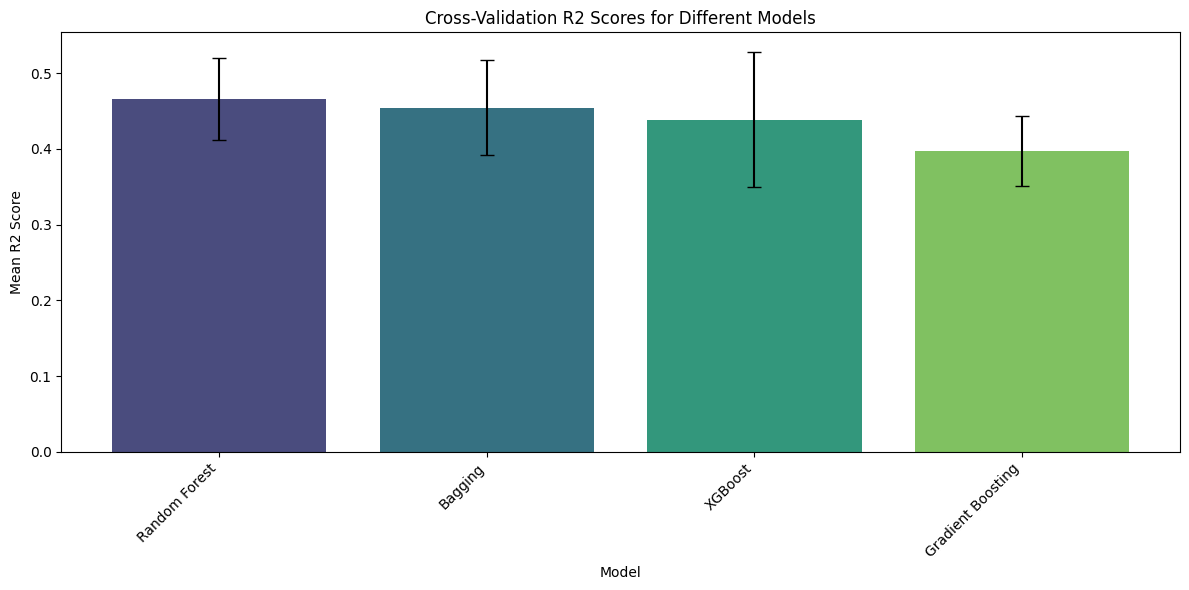

In [ ]:
# Plotting the cross-validation results
cv_df = pd.DataFrame({
    'Model': [name for name in cv_results.keys()],
    'Mean R2': [scores.mean() for scores in cv_results.values()],
    'Std Dev R2': [scores.std() for scores in cv_results.values()]
}).sort_values('Mean R2', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='Model', y='Mean R2', data=cv_df, palette='viridis', hue='Model', legend=False)
plt.errorbar(x=cv_df['Model'], y=cv_df['Mean R2'], yerr=cv_df['Std Dev R2'],
             fmt='none', color='black', capsize=5, label='Standard Deviation')
plt.title('Cross-Validation R2 Scores for Different Models')
plt.xlabel('Model')
plt.ylabel('Mean R2 Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### ── Train best model with hyperparameter tuning ─────────────

In [ ]:

from sklearn.model_selection import GridSearchCV

# XGBoost params to try
xgb_params = {
    'n_estimators'    : [100, 200, 300],
    'max_depth'       : [3, 5, 7],
    'learning_rate'   : [0.01, 0.05, 0.1],
    'subsample'       : [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}



In [ ]:
# ── 1. GridSearch with BASELINE features ───────────────────
xgb_baseline = GridSearchCV(
    XGBRegressor(random_state=42, verbosity=2),
    xgb_params,
    cv      = 3,
    scoring = 'r2',
    n_jobs  = -1,
    verbose = 1
)
xgb_baseline.fit(X_tr[baseline_features], y_tr)

print("Baseline Best params:", xgb_baseline.best_params_)
print("Baseline Best CV R2 :", xgb_baseline.best_score_)

Fitting 3 folds for each of 108 candidates, totalling 324 fits
[14:32:17] INFO: /__w/xgboost/xgboost/src/data/iterative_dmatrix.cc:56: Finished constructing the `IterativeDMatrix`: (82439, 6, 494634).
Baseline Best params: {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.8}
Baseline Best CV R2 : 0.2549517023485917


In [ ]:
# ── 2. GridSearch with GRAPH features ──────────────────────
xgb_graph = GridSearchCV(
    XGBRegressor(random_state=42, verbosity=3),
    xgb_params,
    cv      = 3,
    scoring = 'r2',
    n_jobs  = -1,
    verbose = 1
)
xgb_graph.fit(X_tr[graph_features], y_tr)

print("Graph Best params:", xgb_graph.best_params_)
print("Graph Best CV R2 :", xgb_graph.best_score_)

Fitting 3 folds for each of 108 candidates, totalling 324 fits
[14:39:04] ======== Monitor (0): HostSketchContainer ========
[14:39:04] AllReduce: 0.007391s, 1 calls @ 7391us

[14:39:04] MakeCuts: 0.007449s, 1 calls @ 7449us

[14:39:04] INFO: /__w/xgboost/xgboost/src/data/iterative_dmatrix.cc:56: Finished constructing the `IterativeDMatrix`: (82439, 13, 1071707).
[14:39:04] DEBUG: /__w/xgboost/xgboost/src/gbm/gbtree.cc:127: Using tree method: 0
[14:39:05] ======== Monitor (0): GBTree ========
[14:39:05] BoostNewTrees: 1.20551s, 200 calls @ 1205508us

[14:39:05] CommitModel: 0.000311s, 200 calls @ 311us

[14:39:05] ======== Monitor (0): HistUpdater ========
[14:39:05] BuildHistogram: 0.24988s, 1200 calls @ 249880us

[14:39:05] EvaluateSplits: 0.240746s, 1400 calls @ 240746us

[14:39:05] InitData: 0.014471s, 200 calls @ 14471us

[14:39:05] InitRoot: 0.222354s, 200 calls @ 222354us

[14:39:05] LeafPartition: 0.059811s, 200 calls @ 59811us

[14:39:05] UpdatePosition: 0.354349s, 1400 calls 

In [ ]:
xgb_baseline.best_params_

{'colsample_bytree': 1.0,
 'learning_rate': 0.05,
 'max_depth': 5,
 'n_estimators': 100,
 'subsample': 0.8}

In [ ]:
xgb_graph.best_params_

{'colsample_bytree': 0.8,
 'learning_rate': 0.1,
 'max_depth': 7,
 'n_estimators': 200,
 'subsample': 1.0}

In [ ]:
xgb_graph.best_estimator_

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=7,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

### Comparing Baseline vs. Graph-Enhanced XGBoost Models

In [ ]:
comparison_data = {
    'Model': ['XGBoost (Baseline)', 'XGBoost (Graph-Enhanced)'],
    'Best CV R2 Score': [xgb_baseline.best_score_, xgb_graph.best_score_],
    'Best Parameters': [str(xgb_baseline.best_params_), str(xgb_graph.best_params_)]
}

comparison_df = pd.DataFrame(comparison_data)
display(comparison_df)

,Model,Best CV R2 Score,Best Parameters
0,XGBoost (Baseline),0.254952,"{'colsample_bytree': 1.0, 'learning_rate': 0.0..."
1,XGBoost (Graph-Enhanced),0.455304,"{'colsample_bytree': 0.8, 'learning_rate': 0.1..."


In [ ]:
import plotly.graph_objects as go

fig = go.Figure(data=[
    go.Bar(
        name='Best CV R2 Score',
        x=comparison_df['Model'],
        y=comparison_df['Best CV R2 Score'],
        text=comparison_df['Best CV R2 Score'].apply(lambda x: f'{x:.4f}'),
        textposition='outside'
    )
])

fig.update_layout(
    title_text='Comparison of XGBoost Model R2 Scores',
    xaxis_title='Model Type',
    yaxis_title='Best Cross-Validation R2 Score'
)

fig.show()

#### Best Parameters for Each Model

In [ ]:
fig_params = go.Figure(data=[
    go.Table(
        header=dict(values=['Model', 'Parameter', 'Value'],
                    fill_color='paleturquoise',
                    align='left'),
        cells=dict(values=[
            ['XGBoost (Baseline)'] * len(xgb_baseline.best_params_) + ['XGBoost (Graph-Enhanced)'] * len(xgb_graph.best_params_),
            list(xgb_baseline.best_params_.keys()) + list(xgb_graph.best_params_.keys()),
            list(xgb_baseline.best_params_.values()) + list(xgb_graph.best_params_.values())
        ],
        fill_color='lavender',
        align='left'))
])

fig_params.update_layout(title_text='Best Hyperparameters for Baseline and Graph-Enhanced XGBoost')
fig_params.show()

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate(name, model, X, y, features):
    # Predictions done inside
    y_pred = model.predict(X[features])
    y_true = y.values

    mae   = mean_absolute_error(y_true, y_pred)
    rmse  = np.sqrt(mean_squared_error(y_true, y_pred))
    r2    = r2_score(y_true, y_pred)

    pct_error = np.abs(y_pred - y_true) / y_true
    within_15 = (pct_error <= 0.15).mean() * 100
    mape      = pct_error.mean() * 100

    print(f"\n{'='*40}")
    print(f"  {name}")
    print(f"{'='*40}")
    print(f"  MAE          : {mae:.2f} mins")
    print(f"  RMSE         : {rmse:.2f} mins")
    print(f"  R2 Score     : {r2:.4f}")
    print(f"  MAPE         : {mape:.2f}%")
    print(f"  Within 15%   : {within_15:.1f}%")



In [ ]:
# ── Call it ─────────────────────────────────────────────────
evaluate("Baseline — TEST",       xgb_baseline, X_test, y_test, baseline_features)
evaluate("Graph-Enhanced — TEST", xgb_graph,    X_test, y_test, graph_features)


  Baseline — TEST
  MAE          : 16.27 mins
  RMSE         : 51.80 mins
  R2 Score     : 0.1427
  MAPE         : 55.84%
  Within 15%   : 21.4%

  Graph-Enhanced — TEST
  MAE          : 13.64 mins
  RMSE         : 39.38 mins
  R2 Score     : 0.5044
  MAPE         : 47.33%
  Within 15%   : 28.0%


### for visual comparison of final model

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px

def evaluate_visual(name, model, X, y, features):
    y_pred = model.predict(X[features])
    y_true = y.values

    mae   = mean_absolute_error(y_true, y_pred)
    rmse  = np.sqrt(mean_squared_error(y_true, y_pred))
    r2    = r2_score(y_true, y_pred)

    pct_error = np.abs(y_pred - y_true) / y_true
    within_15 = (pct_error <= 0.15).mean() * 100
    mape      = pct_error.mean() * 100

    return pd.Series({
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R2 Score': r2,
        'MAPE': mape,
        'Within 15%': within_15
    })


In [ ]:
# ── Call the new evaluation function ─────────────────────────
baseline_metrics = evaluate_visual("Baseline — TEST", xgb_baseline, X_test, y_test, baseline_features)
graph_metrics = evaluate_visual("Graph-Enhanced — TEST", xgb_graph, X_test, y_test, graph_features)

# Combine results into a DataFrame
metrics_df = pd.DataFrame([baseline_metrics, graph_metrics])
display(metrics_df)

# ── Plotting Metrics ──────────────────────────────────────
def plot_metric(df, metric_col, title, yaxis_title):
    fig = px.bar(df, x='Model', y=metric_col, title=title,
                 text_auto='.2f',  # Automatically format text on bars
                 color='Model',  # Different color for each model
                 color_discrete_sequence=px.colors.qualitative.Plotly)
    fig.update_traces(textposition='outside')
    fig.update_layout(yaxis_title=yaxis_title, hovermode="x unified")
    fig.show()

plot_metric(metrics_df, 'MAE', 'Mean Absolute Error Comparison', 'MAE (minutes)')
plot_metric(metrics_df, 'RMSE', 'Root Mean Squared Error Comparison', 'RMSE (minutes)')
plot_metric(metrics_df, 'R2 Score', 'R2 Score Comparison', 'R2 Score')
plot_metric(metrics_df, 'MAPE', 'Mean Absolute Percentage Error Comparison', 'MAPE (%)')
plot_metric(metrics_df, 'Within 15%', 'Percentage of Trips Within 15% Error', 'Percentage (%)')


,Model,MAE,RMSE,R2 Score,MAPE,Within 15%
0,Baseline — TEST,16.267997,51.800226,0.142680,55.841831,21.396011
1,Graph-Enhanced — TEST,13.640501,39.383935,0.504415,47.327493,27.982388


Infer from above: that graph enhanced model reached 0.14 to 0.5 which is excelent improvement for this kind of logistics

# save the model

In [ ]:
import pickle

# Save the best baseline model
pickle.dump(xgb_baseline, open('baseline_final_model.pkl', 'wb'))

# Save the best graph-enhanced model
pickle.dump(xgb_graph, open('graph_final_model.pkl', 'wb'))

print("Baseline final model saved as 'baseline_final_model.pkl'")
print("Graph-enhanced final model saved as 'graph_final_model.pkl'")

Baseline final model saved as 'baseline_final_model.pkl'
Graph-enhanced final model saved as 'graph_final_model.pkl'


## saving all the necessity models

In [ ]:
import pickle
import json

# ── 1. Save graph itself ────────────────────────────────────
pickle.dump(G, open('graph.pkl', 'wb'))

# ── 2. Save graph metrics (dictionaries) ───────────────────
pickle.dump(betweenness, open('betweenness.pkl', 'wb'))
pickle.dump(in_degree,   open('in_degree.pkl',   'wb'))
pickle.dump(out_degree,  open('out_degree.pkl',  'wb'))
pickle.dump(edge_weights,open('edge_weights.pkl','wb'))


# ── 4. Save label encoder ───────────────────────────────────
pickle.dump(le, open('label_encoder.pkl', 'wb'))

# ── 5. Save training median (for unseen corridors) ─────────
train_median = df_train['corridor_median_delay'].median()
pickle.dump(train_median, open('train_median.pkl', 'wb'))

print("All saved ✅")

All saved ✅


# demo by loading all

In [ ]:
df_test = pd.read_csv("/content/df_test.csv")
df_test

,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,od_end_time,...,segment_osrm_distance,segment_factor,segment_delay_ratio,trip_delay_ratio,segment_delay_ratio_capped,segment_is_delayed,trip_is_delayed,hour_of_day,day_of_week,month
0,2018-09-29 22:21:45.149226,thanos::sroute:0904e75c-b3ac-4278-96cf-802835a...,FTL,trip-153825970514894360,IND141003AAB,Ludhiana_GillChwk_DC (Punjab),IND142026AAA,Jagraon_DC (Punjab),2018-09-30 02:22:04.138164,2018-09-30 03:42:55.193293,...,23.8100,1.250000,1.250000,1.250000,1.250000,True,True,2,6,9
1,2018-09-29 22:21:45.149226,thanos::sroute:0904e75c-b3ac-4278-96cf-802835a...,FTL,trip-153825970514894360,IND141003AAB,Ludhiana_GillChwk_DC (Punjab),IND142026AAA,Jagraon_DC (Punjab),2018-09-30 02:22:04.138164,2018-09-30 03:42:55.193293,...,16.8540,1.357143,1.357143,1.290323,1.357143,True,True,2,6,9
2,2018-09-29 22:21:45.149226,thanos::sroute:0904e75c-b3ac-4278-96cf-802835a...,FTL,trip-153825970514894360,IND142026AAA,Jagraon_DC (Punjab),IND141109AAA,Raikot_DC (Punjab),2018-09-30 03:42:55.193293,2018-09-30 05:12:34.503322,...,23.3491,1.457143,1.457143,1.457143,1.457143,True,True,3,6,9
3,2018-09-29 22:21:45.149226,thanos::sroute:0904e75c-b3ac-4278-96cf-802835a...,FTL,trip-153825970514894360,IND141109AAA,Raikot_DC (Punjab),IND000000ACA,Ludhiana_MilrGanj_HB (Punjab),2018-09-30 05:12:34.503322,2018-09-30 06:44:42.320422,...,32.6991,0.911111,0.911111,0.911111,0.911111,False,False,5,6,9
4,2018-09-29 22:21:45.149226,thanos::sroute:0904e75c-b3ac-4278-96cf-802835a...,FTL,trip-153825970514894360,IND141109AAA,Raikot_DC (Punjab),IND000000ACA,Ludhiana_MilrGanj_HB (Punjab),2018-09-30 05:12:34.503322,2018-09-30 06:44:42.320422,...,19.0379,0.740741,0.740741,1.070175,0.740741,False,False,5,6,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39213,2018-10-01 18:17:37.047270,thanos::sroute:4029a8a2-6c74-4b7e-a6d8-f9e069f...,FTL,trip-153841785704702048,IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),IND562132AAA,Bangalore_Nelmngla_H (Karnataka),2018-10-02 09:02:19.284969,2018-10-04 10:12:02.765216,...,28.5248,1.750000,1.750000,1.769437,1.750000,True,True,9,1,10
39214,2018-10-01 18:17:37.047270,thanos::sroute:4029a8a2-6c74-4b7e-a6d8-f9e069f...,FTL,trip-153841785704702048,IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),IND562132AAA,Bangalore_Nelmngla_H (Karnataka),2018-10-02 09:02:19.284969,2018-10-04 10:12:02.765216,...,28.8611,1.750000,1.750000,1.769180,1.750000,True,True,9,1,10
39215,2018-10-01 18:17:37.047270,thanos::sroute:4029a8a2-6c74-4b7e-a6d8-f9e069f...,FTL,trip-153841785704702048,IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),IND562132AAA,Bangalore_Nelmngla_H (Karnataka),2018-10-02 09:02:19.284969,2018-10-04 10:12:02.765216,...,27.4406,1.263158,1.263158,1.762402,1.263158,True,True,9,1,10
39216,2018-10-01 18:17:37.047270,thanos::sroute:4029a8a2-6c74-4b7e-a6d8-f9e069f...,FTL,trip-153841785704702048,IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),IND562132AAA,Bangalore_Nelmngla_H (Karnataka),2018-10-02 09:02:19.284969,2018-10-04 10:12:02.765216,...,36.7167,1.346154,1.346154,1.766301,1.346154,True,True,9,1,10


In [ ]:
# ── 3. Define baseline features (NO graph features) ────────
baseline_features = [
    'segment_osrm_time',
    'segment_osrm_distance',
    'route_type_encoded',
    'hour_of_day',
    'day_of_week',
    'month'
]

# Graph-enhanced features (adds graph info on top)
graph_features = baseline_features + [
    'src_betweenness',
    'dst_betweenness',
    'src_in_degree',
    'src_out_degree',
    'dst_in_degree',
    'dst_out_degree',
    'corridor_median_delay'
]
target = 'segment_actual_time'

In [ ]:
# Load everything back
import pickle

G             = pickle.load(open('graph.pkl',         'rb'))
betweenness   = pickle.load(open('betweenness.pkl',   'rb'))
in_degree     = pickle.load(open('in_degree.pkl',     'rb'))
out_degree    = pickle.load(open('out_degree.pkl',    'rb'))
edge_weights  = pickle.load(open('edge_weights.pkl',  'rb'))
le            = pickle.load(open('label_encoder.pkl', 'rb'))
train_median  = pickle.load(open('train_median.pkl',  'rb'))

In [ ]:
# ── 1. Map graph features onto df_test ─────────────────────
df_test['src_betweenness'] = df_test['source_center'].map(betweenness)
df_test['dst_betweenness'] = df_test['destination_center'].map(betweenness)

df_test['src_in_degree']  = df_test['source_center'].map(in_degree)
df_test['src_out_degree'] = df_test['source_center'].map(out_degree)
df_test['dst_in_degree']  = df_test['destination_center'].map(in_degree)
df_test['dst_out_degree'] = df_test['destination_center'].map(out_degree)

df_test['corridor_median_delay'] = df_test.apply(
    lambda r: edge_weights.get(
        (r['source_center'], r['destination_center']), np.nan
    ), axis=1
)

# Fill unseen corridors with training median

df_test['corridor_median_delay'] = df_test['corridor_median_delay'].fillna(train_median)

# ── 2. Encode route_type using SAME encoder from training ───
df_test['route_type_encoded'] = le.transform(df_test['route_type'])

In [ ]:
# split the data in X and y
X_test = df_test[graph_features].dropna()
y_test = df_test.loc[X_test.index, target]

In [ ]:
import pickle

# Load the saved models
loaded_baseline_model = pickle.load(open('baseline_final_model.pkl', 'rb'))
print("Loaded baseline model:")

loaded_graph_model = pickle.load(open('graph_final_model.pkl', 'rb'))
print("Loaded graph-enhanced model:")

# Evaluate the loaded models
print("\nEvaluating loaded models:")
evaluate("Loaded Baseline — TEST", loaded_baseline_model, X_test, y_test, baseline_features)
evaluate("Loaded Graph-Enhanced — TEST", loaded_graph_model, X_test, y_test, graph_features)

Loaded baseline model:
Loaded graph-enhanced model:

Evaluating loaded models:

  Loaded Baseline — TEST
  MAE          : 16.27 mins
  RMSE         : 51.80 mins
  R2 Score     : 0.1427
  MAPE         : 55.84%
  Within 15%   : 21.4%
[17:26:16] DEBUG: /__w/xgboost/xgboost/src/gbm/gbtree.cc:127: Using tree method: 0

  Loaded Graph-Enhanced — TEST
  MAE          : 13.64 mins
  RMSE         : 39.38 mins
  R2 Score     : 0.5044
  MAPE         : 47.33%
  Within 15%   : 28.0%


In [ ]:
y_preds = loaded_graph_model.predict(X_test[graph_features])
y_preds

array([24.308907, 22.940626, 38.764847, ..., 36.438374, 39.754932,
       50.93928 ], dtype=float32)

# prepareing data from raw user input to prediction

In [ ]:
# ── Build city name → center code mapping from df_train ────
source_map = df[['source_center', 'source_name']].drop_duplicates()
dest_map   = df[['destination_center', 'destination_name']].drop_duplicates()

# Filter out any NaN names before building dict
source_map = source_map.dropna(subset=['source_name'])
dest_map   = dest_map.dropna(subset=['destination_name'])

# name → code dictionaries
name_to_src_code = dict(zip(
    source_map['source_name'].str.lower().str.strip(),
    source_map['source_center']
))
name_to_dst_code = dict(zip(
    dest_map['destination_name'].str.lower().str.strip(),
    dest_map['destination_center']
))

# Merge both (any facility can be source or destination)
name_to_code = {**name_to_src_code, **name_to_dst_code}

print(f"Total known facility names: {len(name_to_code)}")
print("\nSample entries:")
for k,v in list(name_to_code.items())[:5]:
    print(f"  '{k}' → {v}")

Total known facility names: 1643

Sample entries:
  'anand_vunagar_dc (gujarat)' → IND388121AAA
  'khambhat_motvddpp_d (gujarat)' → IND388620AAB
  'bhiwandi_mankoli_hb (maharashtra)' → IND421302AAG
  'lowerparel_cp (maharashtra)' → IND400011AAA
  'bangalore_nelmngla_h (karnataka)' → IND562132AAA


In [ ]:
pickle.dump(name_to_code, open('name_to_code.pkl', 'wb'))

print("Saved name to code✅")

Saved name to code✅


In [ ]:
df_train = pd.read_csv("/content/df_train.csv")

In [ ]:
# ── Learn distance to osrm_time ratio from training data ───
osrm_speed = (df_train['segment_osrm_distance'] /
              df_train['segment_osrm_time']).median()

print(f"Median OSRM speed: {osrm_speed:.2f} km/min")
print(f"Which is:          {osrm_speed*60:.1f} km/hr")

# Also learn by route type
osrm_speed_by_route = (
    df_train.groupby('route_type')
    .apply(lambda x: (x['segment_osrm_distance'] /
                      x['segment_osrm_time']).median())
)
print("\nOSRM speed by route type:")
print(osrm_speed_by_route)

Median OSRM speed: 1.36 km/min
Which is:          81.8 km/hr

OSRM speed by route type:
route_type
Carting    1.120719
FTL        1.420147
dtype: float64


In [ ]:
pickle.dump(osrm_speed,          open('osrm_speed.pkl',          'wb'))
pickle.dump(osrm_speed_by_route, open('osrm_speed_by_route.pkl', 'wb'))

print("Saved ✅")

Saved ✅


In [ ]:
import pickle

baseline_final_model = pickle.load(open('baseline_final_model.pkl', 'rb'))
graph_final_model = pickle.load(open('graph_final_model.pkl', 'rb'))
osrm_speed = pickle.load(open('osrm_speed.pkl', 'rb'))
osrm_speed_by_route = pickle.load(open('osrm_speed_by_route.pkl', 'rb'))
name_to_code = pickle.load(open('name_to_code.pkl','rb'))

### helper to find best match

In [ ]:
# ── Helper to find best match ───────────────────────────────
from difflib import get_close_matches

def resolve_facility(user_input):
    cleaned = str(user_input).lower().strip()

    # Exact match
    if cleaned in name_to_code:
        return name_to_code[cleaned], user_input

    # Check if user input is contained in any key
    # e.g. 'mumbai' found in 'mumbai hub - andheri'
    contains_matches = [
        k for k in name_to_code.keys()
        if isinstance(k, str) and cleaned in k
    ]

    if contains_matches:
        print(f"\n  '{user_input}' matched these facilities:")
        for i, match in enumerate(contains_matches[:5]):
            print(f"    [{i+1}] {match.title()}")

        choice = input("  Enter number (or 0 to cancel): ").strip()
        if choice.isdigit() and 1 <= int(choice) <= len(contains_matches[:5]):
            chosen = contains_matches[int(choice)-1]
            return name_to_code[chosen], chosen.title()
        else:
            return None, None

    # Fuzzy match as fallback (lowered cutoff)
    valid_keys = [k for k in name_to_code.keys() if isinstance(k, str)]
    close = get_close_matches(
        cleaned,
        valid_keys,
        n        = 5,      # show more options
        cutoff   = 0.25    # very relaxed ← 25% matches required
    )

    if close:
        print(f"\n  '{user_input}' not found exactly.")
        print(f"  Did you mean one of these?")
        for i, match in enumerate(close):
            print(f"    [{i+1}] {match.title()}")

        choice = input("  Enter number (or 0 to cancel): ").strip()
        if choice.isdigit() and 1 <= int(choice) <= len(close):
            chosen = close[int(choice)-1]
            return name_to_code[chosen], chosen.title()
        else:
            return None, None

    print(f"  ❌ '{user_input}' not recognized in the network.")
    print(f"  Try checking available cities with: show_available_cities('{user_input}')")
    return None, None

#### prediction function

In [ ]:
def predict_delivery_eta(
    source,
    destination,
    route_type ,
    distance_km=None,        # ← only input needed from user
    hour_of_day=None,
    day_of_week=None,
    month=None,
    model=None
):
    """
    source       : str   → city name  (e.g. 'Mumbai')
    destination  : str   → city name  (e.g. 'Pune')
    route_type   : str   → 'FTL' or 'Carting'
    distance_km  : float → approximate road distance in km
    hour_of_day  : int   → hour of departure (0-23)
    day_of_week  : int   → 0=Monday ... 6=Sunday
    month        : int   → 1-12
    model        : optional → defaults to graph model
    """

    # ── Resolve city names ───────────────────────────────────
    print("\nResolving facility names...")
    src_code, src_name = resolve_facility(source)
    dst_code, dst_name = resolve_facility(destination)

    if src_code is None or dst_code is None:
        print("❌ Could not resolve facility. Prediction cancelled.")
        return None

    ###############

    # ── 3. Define baseline features (NO graph features) ────────
    baseline_features = [
        'segment_osrm_time',
        'segment_osrm_distance',
        'route_type_encoded',
        'hour_of_day',
        'day_of_week',
        'month'
    ]

    # Graph-enhanced features (adds graph info on top)
    graph_features = baseline_features + [
        'src_betweenness',
        'dst_betweenness',
        'src_in_degree',
        'src_out_degree',
        'dst_in_degree',
        'dst_out_degree',
        'corridor_median_delay'
    ]
    target = 'segment_actual_time'

    # ── Estimate osrm_time from distance ────────────────────
    route_upper = route_type.upper()
    if route_upper in osrm_speed_by_route:
        speed = osrm_speed_by_route[route_upper]
    else:
        speed = osrm_speed   # fallback to overall median

    osrm_time     = distance_km / speed   # in minutes
    osrm_distance = distance_km

    print(f"  Estimated OSRM time: {osrm_time:.1f} mins "
          f"({osrm_time/60:.1f} hrs) at {speed*60:.0f} km/hr")

    # ── Select model ─────────────────────────────────────────
    if model is None:
        model         = graph_final_model
        features_used = graph_features
        model_name    = "Graph-Enhanced Model"
    if model == baseline_final_model:
        features_used = baseline_features
        model_name    = "Baseline Model"
    else:
        features_used = graph_features
        model_name    = "Graph-Enhanced Model"

    # ── Encode route type ────────────────────────────────────
    try:
        route_encoded = le.transform([route_type])[0]
    except:
        print(f"❌ Invalid route_type '{route_type}'. Use 'FTL' or 'Carting'")
        return None

    # ── Build feature row ────────────────────────────────────
    row = {
        'segment_osrm_time'     : osrm_time,
        'segment_osrm_distance' : osrm_distance,
        'route_type_encoded'    : route_encoded,
        'hour_of_day'           : hour_of_day,
        'day_of_week'           : day_of_week,
        'month'                 : month,
    }

    if features_used == graph_features:
        row['src_betweenness']       = betweenness.get(src_code, 0)
        row['dst_betweenness']       = betweenness.get(dst_code, 0)
        row['src_in_degree']         = in_degree.get(src_code, 0)
        row['src_out_degree']        = out_degree.get(src_code, 0)
        row['dst_in_degree']         = in_degree.get(dst_code, 0)
        row['dst_out_degree']        = out_degree.get(dst_code, 0)
        row['corridor_median_delay'] = edge_weights.get(
                                         (src_code, dst_code),
                                         train_median
                                       )

    # ── Predict ──────────────────────────────────────────────
    input_df   = pd.DataFrame([row])[features_used]
    prediction = model.predict(input_df)[0]

    delay_ratio = prediction / osrm_time
    extra_time  = prediction - osrm_time

    # ── Display ──────────────────────────────────────────────
    print(f"\n{'='*45}")
    print(f"  ETA PREDICTION RESULT")
    print(f"{'='*45}")
    print(f"  Model Used       : {model_name}")
    print(f"  Source           : {src_name.title()}")
    print(f"  Destination      : {dst_name.title()}")
    print(f"  Route Type       : {route_upper}")
    print(f"  Distance         : {distance_km:.0f} km")
    print(f"  OSRM Estimate    : {osrm_time:.1f} mins")
    print(f"  Predicted Actual : {prediction:.1f} mins")
    print(f"  Delay Factor     : {delay_ratio:.2f}x OSRM")
    print(f"  Extra Delay      : +{extra_time:.1f} mins")
    print(f"  Expected Arrival : ~{prediction/60:.1f} hours")
    print(f"{'='*45}")

    return prediction

In [ ]:
# Normal person just types city names
predict_delivery_eta(
    source       = '(maharashtra)',
    destination  = '_bilaspur)',
    route_type   = 'FTL',
    distance_km  = 150.0,
    hour_of_day  = 14,
    day_of_week  = 2,
    month        = 6
)




Resolving facility names...

  '(maharashtra)' matched these facilities:
    [1] Bhiwandi_Mankoli_Hb (Maharashtra)
    [2] Lowerparel_Cp (Maharashtra)
    [3] Nanded_Aswningr_I (Maharashtra)
    [4] Loha_Sivjicwk_D (Maharashtra)
    [5] Gangakher_Busstand_D (Maharashtra)
  Enter number (or 0 to cancel): 3

  '_bilaspur)' not found exactly.
  Did you mean one of these?
    [1] Gurgaon_Bilaspur_P (Haryana)
    [2] Gurgaon_Bilaspur_Rp (Haryana)
    [3] Gurgaon_Bilaspur_Hb (Haryana)
    [4] Patiala (Punjab)
    [5] Bilaspur_Torwa_Dc (Chhattisgarh)
  Enter number (or 0 to cancel): 4
  Estimated OSRM time: 105.6 mins (1.8 hrs) at 85 km/hr

  ETA PREDICTION RESULT
  Model Used       : Graph-Enhanced Model
  Source           : Nanded_Aswningr_I (Maharashtra)
  Destination      : Patiala (Punjab)
  Route Type       : FTL
  Distance         : 150 km
  OSRM Estimate    : 105.6 mins
  Predicted Actual : 55.5 mins
  Delay Factor     : 0.53x OSRM
  Extra Delay      : +-50.1 mins
  Expected Arrival 

np.float32(55.5156)

In [ ]:
# Normal person just types city names
predict_delivery_eta(
    source       = 'mumbai_bhandup west_dc',
    destination  = 'gurgaon',
    route_type   = 'FTL',
    distance_km= 150.0,
    hour_of_day  = 14,
    day_of_week  = 2,
    month        = 6
)




Resolving facility names...

  'mumbai_bhandup west_dc' matched these facilities:
    [1] Mumbai_Bhandup West_Dc (Maharashtra)
  Enter number (or 0 to cancel): 1

  'gurgaon' matched these facilities:
    [1] Gurgaon_Begumpur_Cp (Haryana)
    [2] Gurgaon_Bilaspur_Hb (Haryana)
    [3] Gurgaon_Central_D_15 (Haryana)
    [4] Gurgaon_Bilaspur_Rp (Haryana)
    [5] Gurgaon_Kadipur (Haryana)
  Enter number (or 0 to cancel): 4

  ETA PREDICTION RESULT
  Model Used       : Graph-Enhanced Model
  Source           : Mumbai_Bhandup West_Dc (Maharashtra)
  Destination      : Gurgaon_Bilaspur_Rp (Haryana)
  Route Type       : FTL
  OSRM Estimate    : 120.0 mins
  Predicted Actual : 292.2 mins
  Delay Factor     : 2.44x OSRM
  Extra Time       : +172.2 mins


np.float32(292.21826)

In [ ]:
# Total known facility names: 1643

# Sample entries:
#   'anand_vunagar_dc (gujarat)' → IND388121AAA
#   'khambhat_motvddpp_d (gujarat)' → IND388620AAB
#   'bhiwandi_mankoli_hb (maharashtra)' → IND421302AAG
#   'lowerparel_cp (maharashtra)' → IND400011AAA
#   'bangalore_nelmngla_h (karnataka)' → IND562132AAA


In [ ]:
# Even with typo — fuzzy match handles it
predict_delivery_eta(
    source       = 'Mumbay',   # typo ✅ handled
    destination  = 'Pun',      # partial ✅ handled
    route_type   = 'FTL',
    distance_km  = 150.0,
    hour_of_day  = 14,
    day_of_week  = 2,
    month        = 6
)


Resolving facility names...

  'Mumbay' not found exactly.
  Did you mean one of these?
    [1] Mumbai_Kalyan (Maharashtra)
    [2] Ambala (Haryana)
    [3] Mumbai Hub (Maharashtra)
    [4] Jamui_Mehsouri_D (Bihar)
    [5] Mumbai_Skynet_Int (Maharashtra)
  Enter number (or 0 to cancel): 2

  'Pun' matched these facilities:
    [1] Ludhiana_Gillchwk_Dc (Punjab)
    [2] Jagraon_Dc (Punjab)
    [3] Raikot_Dc (Punjab)
    [4] Ludhiana_Milrganj_Hb (Punjab)
    [5] Jalandhar_Dpc (Punjab)
  Enter number (or 0 to cancel): 1

  ETA PREDICTION RESULT
  Model Used       : Graph-Enhanced Model
  Source           : Ambala (Haryana)
  Destination      : Ludhiana_Gillchwk_Dc (Punjab)
  Route Type       : FTL
  OSRM Estimate    : 120.0 mins
  Predicted Actual : 292.2 mins
  Delay Factor     : 2.44x OSRM
  Extra Time       : +172.2 mins


np.float32(292.21826)

In [ ]:
# Even with typo — fuzzy match handles it
predict_delivery_eta(
    source       = 'kolkata',   # typo ✅ handled
    destination  = 'delhi',      # partial ✅ handled
    route_type   = 'Carting',
    distance_km= 150.0,
    hour_of_day  = 14,
    day_of_week  = 2,
    month        = 6
)


Resolving facility names...

  'kolkata' matched these facilities:
    [1] Kolkata_Dankuni_Hb (West Bengal)
    [2] Kolkata_North_I_4 (West Bengal)
    [3] Kolkata_Trtllard_L (West Bengal)
    [4] Kolkata_Narynpur_C (West Bengal)
    [5] Kolkata_Dankuni_P (West Bengal)
  Enter number (or 0 to cancel): 2

  'delhi' matched these facilities:
    [1] Delhi_Airport_H (Delhi)
    [2] Delhi_North_R_8 (Delhi)
    [3] Del_Okhla_Pc (Delhi)
    [4] Delhi_Nangli_Ip (Delhi)
    [5] Delhi_Gateway_Hb (Delhi)
  Enter number (or 0 to cancel): 3
  Estimated OSRM time: 110.1 mins (1.8 hrs) at 82 km/hr
❌ Invalid route_type 'Carting'. Use 'FTL' or 'Carting'


In [ ]:
# Even with typo — fuzzy match handles it
predict_delivery_eta(
    source       = 'kolkata',   # typo ✅ handled
    destination  = 'delhi',      # partial ✅ handled
    route_type   = 'FTL',
    osrm_time    = 120.0,
    osrm_distance= 150.0,
    hour_of_day  = 14,
    day_of_week  = 2,
    month        = 6,
    model = baseline_final_model
)


Resolving facility names...

  'kolkata' matched these facilities:
    [1] Kolkata_Dankuni_Hb (West Bengal)
    [2] Kolkata_North_I_4 (West Bengal)
    [3] Kolkata_Trtllard_L (West Bengal)
    [4] Kolkata_Narynpur_C (West Bengal)
    [5] Kolkata_Dankuni_P (West Bengal)
  Enter number (or 0 to cancel): 3

  'delhi' matched these facilities:
    [1] Delhi_Airport_H (Delhi)
    [2] Delhi_North_R_8 (Delhi)
    [3] Del_Okhla_Pc (Delhi)
    [4] Delhi_Nangli_Ip (Delhi)
    [5] Delhi_Gateway_Hb (Delhi)
  Enter number (or 0 to cancel): 2

  ETA PREDICTION RESULT
  Model Used       : Baseline Model
  Source           : Kolkata_Trtllard_L (West Bengal)
  Destination      : Delhi_North_R_8 (Delhi)
  Route Type       : FTL
  OSRM Estimate    : 120.0 mins
  Predicted Actual : 315.4 mins
  Delay Factor     : 2.63x OSRM
  Extra Time       : +195.4 mins


np.float32(315.36227)

In [ ]:
# Even with typo — fuzzy match handles it
predict_delivery_eta(
    source       = 'kolkata',   # typo ✅ handled
    destination  = 'delhi',      # partial ✅ handled
    route_type   = 'Carting',
    distance_km= 150.0,
    hour_of_day  = 14,
    day_of_week  = 2,
    month        = 6,
    model = baseline_final_model
)


Resolving facility names...

  'kolkata' matched these facilities:
    [1] Kolkata_Dankuni_Hb (West Bengal)
    [2] Kolkata_North_I_4 (West Bengal)
    [3] Kolkata_Trtllard_L (West Bengal)
    [4] Kolkata_Narynpur_C (West Bengal)
    [5] Kolkata_Dankuni_P (West Bengal)
  Enter number (or 0 to cancel): 3

  'delhi' matched these facilities:
    [1] Delhi_Airport_H (Delhi)
    [2] Delhi_North_R_8 (Delhi)
    [3] Del_Okhla_Pc (Delhi)
    [4] Delhi_Nangli_Ip (Delhi)
    [5] Delhi_Gateway_Hb (Delhi)
  Enter number (or 0 to cancel): 2
  Estimated OSRM time: 110.1 mins (1.8 hrs) at 82 km/hr

  ETA PREDICTION RESULT
  Model Used       : Baseline Model
  Source           : Kolkata_Trtllard_L (West Bengal)
  Destination      : Delhi_North_R_8 (Delhi)
  Route Type       : CARTING
  Distance         : 150 km
  OSRM Estimate    : 110.1 mins
  Predicted Actual : 72.0 mins
  Delay Factor     : 0.65x OSRM
  Extra Delay      : +-38.1 mins
  Expected Arrival : ~1.2 hours


np.float32(72.02481)

In [ ]:
# Even with typo — fuzzy match handles it
predict_delivery_eta(
    source       = 'xxxx',   # typo ✅ handled
    destination  = 'yyyy',      # partial ✅ handled
    route_type   = 'FTL',
    osrm_time    = 120.0,
    osrm_distance= 150.0,
    hour_of_day  = 14,
    day_of_week  = 2,
    month        = 6
)


Resolving facility names...
  ❌ 'xxxx' not recognized in the network.
  Try checking available cities with: show_available_cities('xxxx')
  ❌ 'yyyy' not recognized in the network.
  Try checking available cities with: show_available_cities('yyyy')
❌ Could not resolve facility names. Prediction cancelled.
